In [1]:
import os

print(os.getcwd())

/Users/vidhi/Desktop/alfido-tech-internship/Task-3 Titanic Survival Prediction


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

In [3]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

print("All libraries imported successfully!")


All libraries imported successfully!


In [5]:
import sys
print(sys.executable)
print(sys.version)


/Library/Frameworks/Python.framework/Versions/3.13/bin/python3
3.13.14 (v3.13.14:fd17997c386, Jun 10 2026, 08:55:00) [Clang 21.0.0 (clang-2100.1.1.101)]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Setup Successful!")

NumPy: 2.5.1
Pandas: 3.0.3
Setup Successful!


In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing[missing["Missing Values"]>0]

,Missing Values,Percentage
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


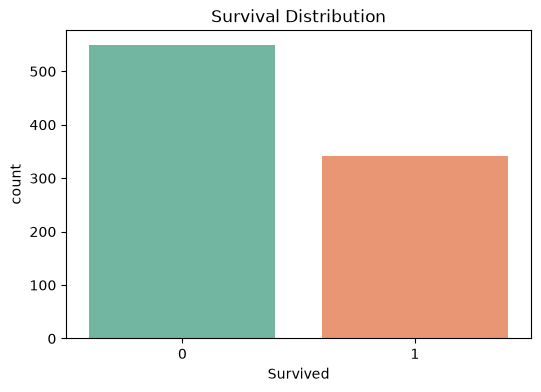

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Survived",
    palette="Set2"
)

plt.title("Survival Distribution")
plt.show()

In [14]:
# Extract Title from Name

df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

# Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Is Alone

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Cabin Available

df["CabinPresent"] = df["Cabin"].notnull().astype(int)

print("Feature Engineering Completed")

Feature Engineering Completed


In [15]:
df[[
    "Name",
    "Title",
    "FamilySize",
    "IsAlone",
    "CabinPresent"
]].head()

,Name,Title,FamilySize,IsAlone,CabinPresent
0,"Braund, Mr. Owen Harris",Mr,2,0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1
2,"Heikkinen, Miss. Laina",Miss,1,1,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1
4,"Allen, Mr. William Henry",Mr,1,1,0


In [16]:
df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ],
    inplace=True
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,CabinPresent
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,0


In [17]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

print(X.shape)
print(y.shape)

(891, 11)
(891,)


In [18]:
categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(exclude="object").columns

print("Categorical Features:")
print(categorical_features)

print()

print("Numerical Features:")
print(numerical_features)

Categorical Features:
Index(['Sex', 'Embarked', 'Title'], dtype='str')

Numerical Features:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone',
       'CabinPresent'],
      dtype='str')


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor Ready")

Preprocessor Ready


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(712, 11)
(179, 11)


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [22]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("All models trained successfully!")

All models trained successfully!


In [23]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.832402,0.800000,0.753623,0.776119,0.868775
2,Gradient Boosting,0.804469,0.783333,0.681159,0.728682,0.838999
1,Random Forest,0.793296,0.728571,0.739130,0.733813,0.830567


In [24]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
       'FamilySize', 'IsAlone', 'CabinPresent'],
      dtype='str')


In [25]:
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'FamilySize', 'IsAlone', 'CabinPresent'],
      dtype='str')


In [26]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 11)
X_test : (179, 11)
y_train: (712,)
y_test : (179,)


In [27]:
print("Training Accuracy")

for name, model in trained_models.items():
    print(name, model.score(X_train, y_train))

print("\nTesting Accuracy")

for name, model in trained_models.items():
    print(name, model.score(X_test, y_test))

Training Accuracy
Logistic Regression 0.8356741573033708
Random Forest 0.9873595505617978
Gradient Boosting 0.9143258426966292

Testing Accuracy
Logistic Regression 0.8324022346368715
Random Forest 0.7932960893854749
Gradient Boosting 0.8044692737430168


In [28]:
print(y_test.value_counts())

Survived
0    110
1     69
Name: count, dtype: int64


In [29]:
print(df.shape)
df.head()

(891, 12)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,CabinPresent
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1,0
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0,1
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1,0


In [30]:
df.isnull().sum()

Survived          0
Pclass            0
Sex               0
Age             177
SibSp             0
Parch             0
Fare              0
Embarked          2
Title             0
FamilySize        0
IsAlone           0
CabinPresent      0
dtype: int64

In [31]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])
df["Title"] = le.fit_transform(df["Title"])

In [33]:
print(df.head())
print(df.isnull().sum())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    1  22.0      1      0   7.2500         2     12   
1         1       1    0  38.0      1      0  71.2833         0     13   
2         1       3    0  26.0      0      0   7.9250         2      9   
3         1       1    0  35.0      1      0  53.1000         2     13   
4         0       3    1  35.0      0      0   8.0500         2     12   

   FamilySize  IsAlone  CabinPresent  
0           2        0             0  
1           2        0             1  
2           1        1             0  
3           2        0             1  
4           1        1             0  
Survived        0
Pclass          0
Sex             0
Age             0
SibSp           0
Parch           0
Fare            0
Embarked        0
Title           0
FamilySize      0
IsAlone         0
CabinPresent    0
dtype: int64


In [34]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features:")
print(X.columns)

Features:
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
       'FamilySize', 'IsAlone', 'CabinPresent'],
      dtype='str')


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(712, 11)
(179, 11)


In [36]:
trained_models = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [37]:
for name, model in trained_models.items():
    print(name)
    print("Train:", model.score(X_train, y_train))
    print("Test :", model.score(X_test, y_test))
    print()

Logistic Regression
Train: 0.8033707865168539
Test : 0.8044692737430168

Random Forest
Train: 0.9845505617977528
Test : 0.7988826815642458

Gradient Boosting
Train: 0.9143258426966292
Test : 0.8044692737430168



In [38]:
results = []

for name, model in trained_models.items():

    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804469,0.757576,0.724638,0.740741,0.855995
2,Gradient Boosting,0.804469,0.793103,0.666667,0.724409,0.825626
1,Random Forest,0.798883,0.732394,0.753623,0.742857,0.839855


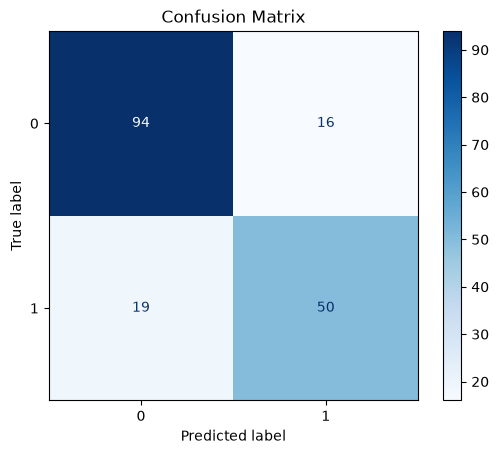

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = trained_models["Logistic Regression"]

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

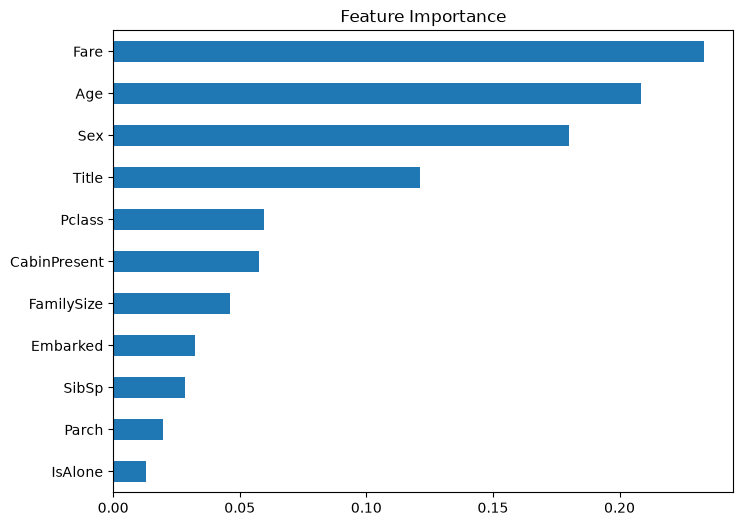

In [40]:
import pandas as pd

feature_importance = pd.Series(
    trained_models["Random Forest"].feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

In [41]:
import joblib

joblib.dump(
    trained_models["Logistic Regression"],
    "titanic_best_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [42]:
sample = X.iloc[[0]]

prediction = trained_models["Logistic Regression"].predict(sample)

print("Prediction:", prediction[0])

Prediction: 0


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results=[]

for name,model in trained_models.items():

    pred=model.predict(X_test)

    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1 Score":f1_score(y_test,pred),
        "ROC-AUC":roc_auc_score(y_test,model.predict_proba(X_test)[:,1])
    })

results_df=pd.DataFrame(results)

results_df.sort_values("Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804469,0.757576,0.724638,0.740741,0.855995
2,Gradient Boosting,0.804469,0.793103,0.666667,0.724409,0.825626
1,Random Forest,0.798883,0.732394,0.753623,0.742857,0.839855


In [44]:
from sklearn.metrics import classification_report

pred=best_model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [46]:
sample=X.iloc[[0]]

prediction=best_model.predict(sample)

print("Prediction:",prediction[0])

print(sample)

Prediction: 0
   Pclass  Sex   Age  SibSp  Parch  Fare  Embarked  Title  FamilySize  \
0       3    1  22.0      1      0  7.25         2     12           2   

   IsAlone  CabinPresent  
0        0             0  


In [47]:
import joblib

joblib.dump(best_model,"titanic_best_model.joblib")

print("Saved Successfully")

Saved Successfully


In [48]:
sample = pd.DataFrame({
    "Pclass":[3],
    "Sex":[1],
    "Age":[25],
    "SibSp":[0],
    "Parch":[0],
    "Fare":[8.05],
    "Embarked":[2],
    "Title":[12],
    "FamilySize":[1],
    "IsAlone":[1],
    "CabinPresent":[0]
})

prediction = trained_models["Logistic Regression"].predict(sample)

print("Predicted Survival:", prediction[0])

if prediction[0] == 1:
    print("Passenger is predicted to Survive")
else:
    print("Passenger is predicted NOT to Survive")

Predicted Survival: 0
Passenger is predicted NOT to Survive


In [49]:
import joblib

joblib.dump(trained_models["Logistic Regression"], "titanic_best_model.joblib")

print("Model saved successfully!")

Model saved successfully!
